<a href="https://colab.research.google.com/github/AnnaEzGa/Dimarts30Abril/blob/main/flow_water.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving MDequil.dcd to MDequil.dcd
Saving system.psf to system.psf


{'MDequil.dcd': b'T\x00\x00\x00CORDd\x00\x00\x00\x88\x13\x00\x00\x88\x13\x00\x00 \xa1\x07\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xe3\x90\'=\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00T\x00\x00\x00\xa4\x00\x00\x00\x02\x00\x00\x00REMARKS FILENAME=MDequil.dcd CREATED BY NAMD                                    REMARKS DATE: 04/30/26 CREATED BY USER: 1665813@uab.cat                         \xa4\x00\x00\x00\x04\x00\x00\x00p\x08\x00\x00\x04\x00\x00\x000\x00\x00\x00\x00\x00\x00\x00\x00\x007@\x00\x00\x00\x00\x00\x00\x00\x00%\x06\x81\x95C\xeb3@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xca-\xc1\xb5\xfe=I@0\x00\x00\x00\xc0!\x00\x005^\x92\xc05^\x92\xc0m\xe7\xbf\xc0\xfa~\xe6\xc0\x83\xc0 \xc1J\x0c4\xc1\xe5\xd0J\xc1\xe5\xd0J\xc1J\x0c4\xc1\x83\xc0 \xc1\xfa~\xe6\xc0m\xe7\xbf\xc0\x08\xac\x98\xc0\xf8S\xaf\xc0\x10X\xfd\xc0\xf

In [ ]:
# Settings
upper_end = 6.754
lower_end = -6.754
output_file = "flow.dat"

In [ ]:
# Load trajectory (change filenames as needed)
u = mda.Universe('system.psf','MDequil.dcd')
wat = u.select_atoms("name OH2")


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [ ]:
def get_status(z_coords):
    status = []
    for z in z_coords:
        if z < lower_end:
            status.append(-1)
        elif z > upper_end:
            status.append(1)
        else:
            status.append(0)
    return np.array(status)

In [ ]:
# Initialization
u.trajectory[0]  # First frame
old_status = get_status(wat.positions[:, 2])
total = 0

In [ ]:
time=[]
instantflow=[]

In [ ]:
with open(output_file, "w") as f:
    for ts in u.trajectory[1:]:
        new_status = get_status(wat.positions[:, 2])
        for old, new in zip(old_status, new_status):
            if old != new and old + new != 0:
                total += new - old
        old_status = new_status.copy()
        time.append(ts.time)
        instantflow.append(total/2.0)
        f.write(f"{ts.frame} {total/2.0}\n")

In [ ]:
# Final output
if total > 0:
    print(f"The net flow is {total / 2.0} water molecules along +z")
elif total < 0:
    print(f"The net flow is {-total / 2.0} water molecules along -z")
else:
    print("The net flow is 0")
print("Time evolution saved in a .dat file")

The net flow is 8.0 water molecules along +z
Time evolution saved in a .dat file


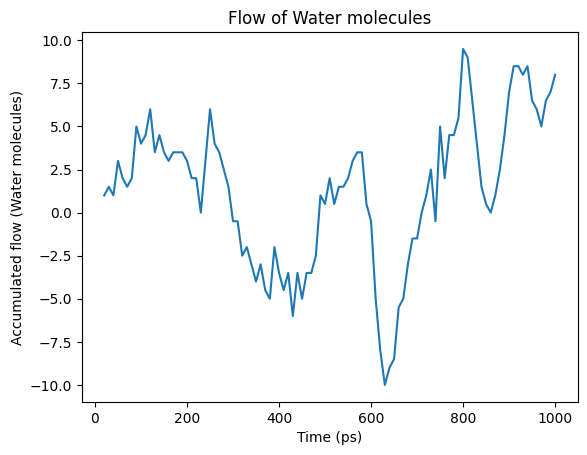

In [ ]:
#Plot
plt.plot(time,instantflow)
plt.xlabel('Time (ps)')
plt.ylabel('Accumulated flow (Water molecules)')
plt.title('Flow of Water molecules')
plt.show()